In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

n = 500

df = pd.DataFrame({
    "user_id": np.arange(1, n+1),
    "country": np.random.choice(["USA", "UK", "Germany", "France"], n),
    "device": np.random.choice(["IOS", "Android"], n),
    "session_length": np.random.randint(1, 60, n),
    "events": np.random.randint(1, 50, n),
    "purchase": np.random.choice([0, 1], n, p=[0.7, 0.3])
})

df.to_json("app_data.json", orient="records")

In [3]:
df = pd.read_json("app_data.json")

df.head()

,user_id,country,device,session_length,events,purchase
0,1,Germany,IOS,54,36,1
1,2,France,IOS,17,45,0
2,3,USA,IOS,9,24,0
3,4,Germany,Android,33,15,0
4,5,Germany,IOS,53,29,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         500 non-null    int64 
 1   country         500 non-null    object
 2   device          500 non-null    object
 3   session_length  500 non-null    int64 
 4   events          500 non-null    int64 
 5   purchase        500 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 23.6+ KB


In [5]:
df.describe()

,user_id,session_length,events,purchase
count,500.000000,500.0000,500.000000,500.000000
mean,250.500000,29.4600,25.990000,0.292000
std,144.481833,17.3515,14.086261,0.455138
min,1.000000,1.0000,1.000000,0.000000
25%,125.750000,14.0000,14.000000,0.000000
50%,250.500000,30.0000,26.000000,0.000000
75%,375.250000,45.0000,38.000000,1.000000
max,500.000000,59.0000,49.000000,1.000000


In [6]:
df.isna().sum()

user_id           0
country           0
device            0
session_length    0
events            0
purchase          0
dtype: int64

In [7]:
avg_session = df["session_length"].mean()

print("Average session length:", avg_session)

Average session length: 29.46


In [8]:
conversion_rate = df["purchase"].mean()

print("Conversion Rate:", conversion_rate)

Conversion Rate: 0.292


In [9]:
device_cr = df.groupby("device")["purchase"].mean()

print("Convertion Rate by device:", device_cr)

Convertion Rate by device: device
Android    0.295276
IOS        0.288618
Name: purchase, dtype: float64


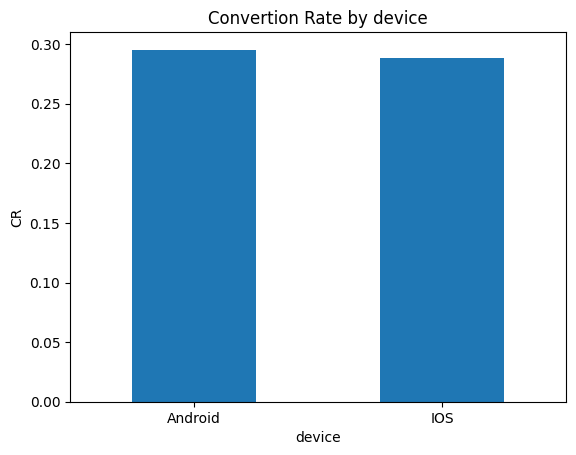

In [10]:
device_cr.plot(kind="bar")
plt.title("Convertion Rate by device")
plt.xticks(rotation=0)
plt.ylabel("CR")
plt.show()

In [11]:
country_cr = df.groupby("country")["purchase"].mean().sort_values(ascending=False)

print("Convertion Rate by country", country_cr)

Convertion Rate by country country
Germany    0.319672
France     0.297297
USA        0.278689
UK         0.268519
Name: purchase, dtype: float64


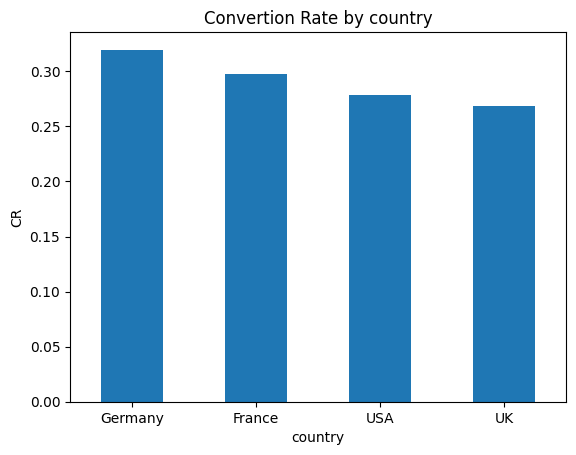

In [12]:
country_cr.plot(kind="bar")
plt.title("Convertion Rate by country")
plt.xticks(rotation=0)
plt.ylabel("CR")
plt.show()

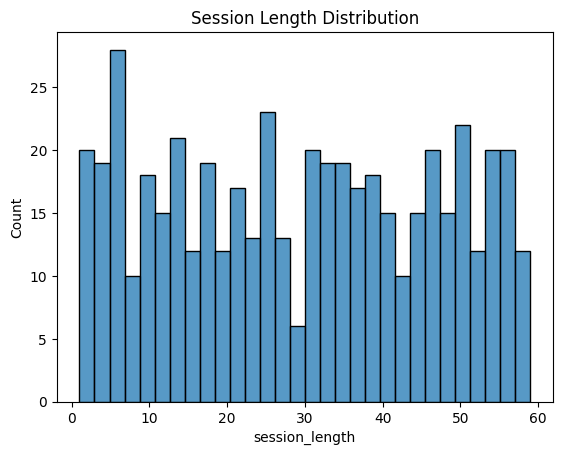

In [14]:
sns.histplot(df["session_length"], bins=30)
plt.title("Session Length Distribution")
plt.show()

In [15]:
def segment_user(x):
    if x < 10:
        return "light"
    elif x < 30:
        return "medium"
    else:
        return "heavy"

df["user_segment"] = df["session_length"].apply(segment_user)

In [18]:
df["user_segment"].value_counts()

user_segment
heavy     254
medium    162
light      84
Name: count, dtype: int64

In [19]:
segment_cr = df.groupby("user_segment")["purchase"].mean()

segment_cr

user_segment
heavy     0.295276
light     0.297619
medium    0.283951
Name: purchase, dtype: float64

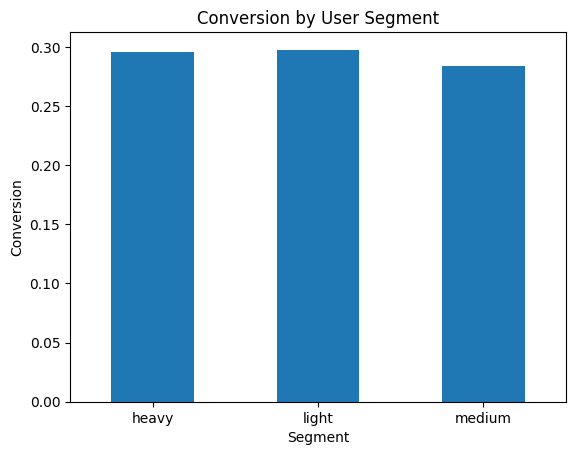

In [22]:
segment_cr.plot(kind="bar")
plt.title("Conversion by User Segment")
plt.xticks(rotation=0)
plt.ylabel("Conversion")
plt.xlabel("Segment")
plt.show()

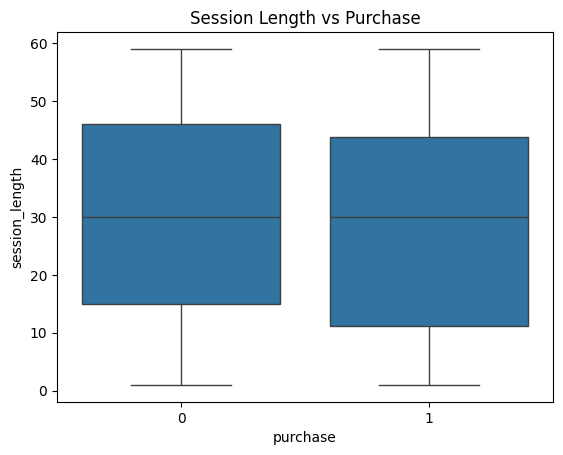

In [23]:
sns.boxplot(
    x="purchase",
    y="session_length",
    data=df
)
plt.title("Session Length vs Purchase")
plt.show()